# Reading in the Data

### Imports and File Paths

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import time as t

# sparse matrix
from scipy.sparse import csc_array, csr_array

# this will handle the supported file formats
from imzy import get_reader

In [4]:
# File paths to .d folder
two_week_path = r"Y:\spraggins\sandbox\spathij\spinal cord injury round 1\spinal cord injury 3\2week_3.9_neg\2week_3.9_neg.d"
four_week_path = r"Y:\spraggins\sandbox\spathij\spinal cord injury round 1\spinal cord injury 3\4week_3.9_neg\4week_3.9_neg.d"

# Give path to reader
path = Path(four_week_path)
reader = get_reader(path)
print(reader)

### Data Exploration

In [5]:
# Calculate Total Ion Count for each pixel
tic = reader.get_tic()
n_pixels = len(tic)
n_mz = len(reader[1][0])

#Print the shape of our data
print("We have " + str(n_pixels) + " pixels.")
print("We have " + str(n_mz) + " m/z values (columns).")

We have 109663 pixels.
We have 255681 m/z values (columns).


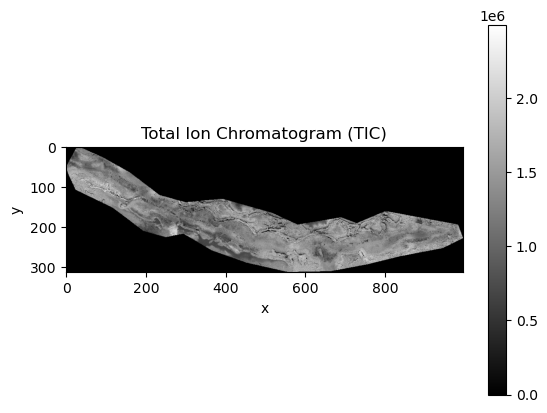

In [6]:
# get TIC array - TIC is returned as a 1D array
tic = reader.get_tic()
# convert the 1d array to 2d for visualization
tic2d = reader.reshape(tic)

# This is what our zebrafish spinal cord looks like
fig, ax = plt.subplots()
im = ax.imshow(tic2d, cmap="gray")
ax.set(title="Total Ion Chromatogram (TIC)", xlabel="x", ylabel="y")
plt.colorbar(im)

In [8]:
# Good candidate for a pixel to align to
x_cond = reader.x_coordinates == 600
y_cond = reader.y_coordinates == 250

base_pixel_idx = np.where(x_cond & y_cond)[0][0]

### Some test things before we read in the data

In [9]:
# This cell is looking at how much space we are saving by converting from dense matrices into sparse matrices.

# Our sparse threshold 
THRESHOLD = 0.0

# Now let's compute how many non-zero data entries we have
vec_size = 0
start_time = t.time()
for i, elem in enumerate(tic):
    mz_vals, intensities = reader[i]
    vec_size += np.count_nonzero(intensities > THRESHOLD)  # Dense format

    if i%1_000 == 0: # Print out
        print(np.round(i/len(tic)*100, 2), '% in', np.round(t.time()-start_time), 's', end='\r')

# Calculate some helpful reminders about how big the data is
total_entries = len(tic) * len(reader[1][0])
nonzero_entries = vec_size
fraction_nonzero = nonzero_entries/total_entries*100
print("We only need " + str(fraction_nonzero) + " percent of our data.")

We only need 13.552266422167255 percent of our data.


Normalization! Here we are using 5-95% Total Ion Count. This makes sure pixels with a big intensity don't screw up our calculations. The cell below doesn't run the normalization. It just sets up the function so that we can normalize each pixel.

In [10]:
def calculate_normalizations_optimized(spectrum: np.ndarray) -> np.ndarray:
    """Calculate various normalizations, optimized version.

    This function expects a float32 spectrum.
    """
    # Filter positive values once and reuse
    positive_spectrum = spectrum[spectrum > 0]

    # Calculating quantiles once for all needed
    if positive_spectrum.size > 1:
        q95, q90, q10, q5 = np.nanquantile(positive_spectrum, [0.95, 0.9, 0.1, 0.05])
    else:
        q95, q90, q10, q5 = 0, 0, 0, 0

    # Using logical indexing with boolean arrays might be faster due to numba optimization
    condition_q95 = spectrum < q95
    condition_q5 = spectrum > q5

    return 1/np.sum(spectrum[condition_q5 & condition_q95])  # 5-95% TIC

OR

In [ ]:
# # Use imzy's precalculated pixel by pixel normalizations

# # you can also obtain normalizations for each pixel
# # the data is returned as dict mapping of 'normalization name' to array of scaling factors
# # the values are to be used as multipliers of the spectra
# norms = reader.get_normalizations()
# # get the names of the available normalizations
# list(norms.keys())

Alignment is performed using the msalign package. Peaks are chosen by someone with knowledge of the biological importance of different m/zs. The cell below is one iteration of the loop we will run to read our data onto our computer.

In [ ]:
# One iteration of loop test-cell
from msalign import Aligner

base_align = reader[base_pixel_idx][0]
peaks = [728.6, 886.5, 904.6, 918.7] # Peaks that are present throughout the sample
# normalization_method = '5-95% TIC'

start_time = t.time()
mz_vals, intensities = reader[1973]
intensities = intensities.astype('float32')
spectrum = intensities.reshape(1, len(intensities))
aligner = Aligner(
    base_align,
    spectrum,
    peaks,
    weights=None,
    return_shifts=True,
    align_by_index=True,
    only_shift=True,
    method="pchip",
)
aligner.run()
aligned_array, shifts_out = aligner.apply(return_shifts=True)
aligned_array = aligned_array.ravel()

norm_factor = calculate_normalizations_optimized(aligned_array) # OR norms[normalization_method][e]

mask    = aligned_array > THRESHOLD
nz_vals = np.log1p(aligned_array[mask] * norm_factor).astype('float16')
nz_idx  = np.where(mask)[0].astype('int32')
n       = len(nz_vals)

finish_time = t.time()
time_elapsed = finish_time - start_time

print("Time for one loop: " + str(time_elapsed))
print("Total time: " + str(time_elapsed*len(tic)/60/60) + " hours.")

Let's look at the pixel we aligned and normalized

In [ ]:
fig, ax = plt.subplots()
ax.plot(base_align, sample)
_ = ax.set(xlabel="m/z", ylabel="Intensity", title="Test spectrum aligned and normalized")

How good was our alignment?

In [ ]:
# Functions to test how good our alignment was
def overlay_plot(ax, x, array, peak):
    """Generate overlay plot, showing each signal and the alignment peak(s)"""
    for i, y in enumerate(array):
        y = (y / y.max()) + (i * 0.2)
        ax.plot(x, y, lw=3)
    ax.axes.get_yaxis().set_visible(False)
    ax.set_xlabel("Index", fontsize=18)
    ax.set_xlim((x[0], x[-1]))
    ax.vlines(peak, *ax.get_ylim())

def find_nearest_index(x, peak):
    return (np.abs(x - peak)).argmin()
    
def plot_peak(ax, x, y, peak, window=100):
    peak_idx = find_nearest_index(x, peak)
    _x = x[peak_idx-window:peak_idx+window]
    _y = y[peak_idx-window:peak_idx+window]
    ax.plot(_x, _y)
    
    ax.axes.get_yaxis().set_visible(False)
    ax.set_xlim((_x[0], _x[-1]))
    ax.vlines(peak, *ax.get_ylim())

def zoom_plot(axs, x, array, aligned_array, peaks):
    for i, y in enumerate(array):
        for j, peak in enumerate(peaks):
            plot_peak(axs[0, j], x, y, peak)
            
    for i, y in enumerate(aligned_array):
        for j, peak in enumerate(peaks):
            plot_peak(axs[1, j], x, y, peak)

# display before and after shifting
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(12, 10))
overlay_plot(ax[0], x, array, peaks)
overlay_plot(ax[1], x, aligned_array, peaks)

# zoom-in on each peak
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(12, 10))
zoom_plot(ax, x, array, aligned_array, peaks)

Should I use imzy's normalization instead of mine??? Might be more efficient?

### Actually Reading the Data In

In [ ]:
# Reading the data into Zarr file format

from msalign import msalign
from msalign import Aligner
import zarr
import numcodecs
import numpy as np

base_align = reader[base_pixel_idx][0]
peaks = [728.6, 886.5, 904.6, 918.7] # Peaks that are present throughout the sample
# normalization_method = '5-95% TIC'

compressor = numcodecs.Blosc(cname="lz4", clevel=5, shuffle=numcodecs.Blosc.SHUFFLE)

store = zarr.open("spectra_sparse.zarr", mode="w")
store.create_dataset("mz_axis",  data=base_align)
store.create_dataset("indptr",   shape=(len(tic)+1,), dtype='int64')
data_ds = store.create_dataset(
    "data",    shape=(nonzero_entries,), dtype='float16',
    chunks=(100_000,), compressor=compressor
)
idx_ds = store.create_dataset(
    "indices", shape=(nonzero_entries,), dtype='int32',
    chunks=(100_000,), compressor=compressor
)

ptr = 0
store["indptr"][0] = 0
start_time = t.time()

for e, _ in enumerate(tic):
    mz_vals, intensities = reader[e]
    intensities = intensities.astype('float32')
    spectrum = intensities.reshape(1, len(intensities))

    aligner = Aligner(
        base_align,
        spectrum,
        peaks,
        weights=None,
        return_shifts=True,
        align_by_index=True,
        only_shift=True,
        method="pchip",
    )
    aligner.run()
    aligned_array, shifts_out = aligner.apply(return_shifts=True)
    aligned_array = aligned_array.ravel()

    norm_factor = calculate_normalizations_optimized(aligned_array) # OR norms[normalization_method][e]

    mask    = aligned_array > THRESHOLD
    nz_vals = np.log1p(aligned_array[mask] * norm_factor).astype('float16')
    nz_idx  = np.where(mask)[0].astype('int32')
    n       = len(nz_vals)

    data_ds[ptr:ptr+n] = nz_vals
    idx_ds[ptr:ptr+n]  = nz_idx

    ptr += n
    store["indptr"][e+1] = ptr

    if e % 1_000 == 0:
        print(np.round(e/len(tic)*100, 2), '% in', np.round(t.time()-start_time), 's', end='\r')

print(f"\nStored {ptr:,} non-zeros")

Code to do it in HDF5.

In [ ]:
# # HDF5

# from msalign import msalign
# from msalign import Aligner
# import h5py

# base_align = reader[base_pixel_idx][0] # Pick a representative pixel (one that's actually in the tissue)
# peaks = [728.6, 886.5, 904.6, 918.7] # Peaks that are present throughout the sample

# with h5py.File("spectra_sparse.h5", "w") as f:
#     # Store CSR components as resizable datasets
#     f.create_dataset("mz_axis", data=base_align)
#     f.create_dataset("indptr",  shape=(len(tic)+1,), dtype='int64')
    
#     # Pre-allocate with estimated size — use your real vec_size if known
#     data_ds = f.create_dataset(
#         "data", shape=(nonzero_entries,), dtype='float16', chunks=(100_000,), compression="gzip"
#     )
#     idx_ds = f.create_dataset(
#         "indices", shape=(nonzero_entries,), dtype='int32', chunks=(100_000,), compression="gzip"
#     )
    
#     ptr = 0
#     f["indptr"][0] = 0

#     start_time = t.time()
#     for e, _ in enumerate(tic):
#         mz_vals, intensities = reader[e]
#         intensities = intensities.astype('float32')
#         spectrum = intensities.reshape(1, len(intensities))
        
#         # Align
#         # instantiate aligner object
#         aligner = Aligner(
#             base_align, 
#             spectrum, 
#             peaks, 
#             weights=None,
#             return_shifts=True,
#             align_by_index=True,
#             only_shift=True,
#             method="pchip",
#         )
#         aligner.run()
#         aligned_array, shifts_out = aligner.apply(return_shifts=True)
#         aligned_array = aligned_array.ravel()  # flatten to 1D after apply()
        
#         # Normalize
#         norm_factor = calculate_normalizations_optimized(aligned_array)
        
#         # Sparse mask
#         mask = aligned_array > THRESHOLD
#         nz_vals = np.log1p(aligned_array[mask] * norm_factor).astype('float16')
#         nz_idx  = np.where(mask)[0].astype('int32')
#         n = len(nz_vals)
        
#         # Extend resizable datasets
#         # data_ds.resize(ptr + n, axis=0)
#         # idx_ds.resize(ptr + n, axis=0)
#         data_ds[ptr:ptr+n] = nz_vals
#         idx_ds[ptr:ptr+n]  = nz_idx
        
#         ptr += n
#         f["indptr"][e+1] = ptr
        
#         if e % 1_000 == 0:
#             print(np.round(e/len(tic)*100, 2), '% in', np.round(t.time()-start_time), 's', end='\r')

# print(f"\nStored {ptr:,} non-zeros")